# Improve Transport Baseline — SISEPUEDE Morocco

**Input:**  `sisepuede_raw_inputs_recalibrated_electricity.csv`  
**Output:** `sisepuede_raw_inputs_recalibrated_electricity_trns_improved.csv`

## Motivation

The current baseline is calibrated **only at the aggregate level** (total IEA energy 2015 = 224 PJ; total transport CO₂ NIR 2022 = 17.90 Mt). The remaining structure (176 of 183 variables) is still the **Bulgarian template** without country-specific adjustments.

## Fixes applied

| # | Variable | Before | After (BAU 2050) | Source / Justification |
|---|---|---|---|---|
| 1 | `frac_trns_fuelmix_aviation_{kerosene,hydrogen}` | 0.87 / 0.13 (entire horizon) | 1.00 / 0.00 (2015–2022) → 0.87 / 0.13 (2050) | RAM/ONDA — Morocco has no aviation hydrogen today |
| 2 | `frac_trns_fuelmix_public_{diesel, NG, electricity}` | 0.83 / 0.12 / 0.001 | 0.89 / 0.0 / 0.10 | Casa+Rabat trams operating since 2011/12. Organic BAU only |
| 3 | `frac_trns_fuelmix_road_heavy_freight_{diesel, E, H₂, gasoline, NG}` | 0.90 / 0 / 0 / 0.10 / 0.003 | 0.945 / 0.04 / 0.01 / 0.005 / 0 | Heavy trucks ~99% diesel; minimal organic shift in BAU (no carbon price, no infra) |
| 4 | `frac_trns_fuelmix_road_heavy_regional_*` | Same as freight | Same as freight | Intercity coaches (CTM/Supratours): same constraints |
| 5 | `frac_trns_pkm_dem_regional_rail_passenger` | 0.003 | 0.045 | ONCF ~5 Bn pkm/yr pre-COVID ÷ 117 Bn ≈ 4% |
| 6 | `frac_trns_pkm_dem_regional_road_light` | 0.836 | 0.794 | Reallocated when rail share is raised |
| 7 | `deminit_trde_private_and_public_per_capita_passenger_km` | 0.66 | 1,200 | Realistic MA urban share (~40% of passenger pkm) |
| 8 | `deminit_trde_regional_per_capita_passenger_km` | 3,161 | 1,962 | Reallocated to preserve total pkm |
| 9 | `elasticity_trde_pkm_to_gdppc_private_and_public` | 0.80 (constant) | 0.80 (2015–2022) → 1.40 (≥2023) | SNBC motorization wave |
| 10 | `elasticity_trde_pkm_to_gdppc_regional` | 0.80 (constant) | 0.80 → 1.40 | SNBC |
| 11 | `elasticity_trde_mtkm_to_gdp_freight` | 0.80 (constant) | 0.80 → 1.20 | SNBC freight |

## Preserved
- Total passenger pkm (urban + regional × population) is preserved to avoid breaking the energy calibration.
- Diesel/gasoline mix of `road_light` (already correct for Morocco post-recalibration).
- Rail fuel mix (52% electric is reasonable for ONCF).

## Important: baseline vs. transformation distinction

The baseline reflects **what Morocco actually has today plus organic trend** — no explicit policy interventions. Aspirational targets like the SNBC NDC (1M EVs by 2030, 5,000 H₂ trucks, 45% electric public transport by 2050, etc.) are encoded as **transformations** under strategy `PFLO:SNBC_NET_ZERO` (id 6005), not in this baseline.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import shutil
from datetime import datetime

INPUT_DIR = Path('/Users/fabianfuentes/git/ssp_morocco/ssp_modeling/input_data')
SRC = INPUT_DIR / 'sisepuede_raw_inputs_recalibrated_electricity.csv'
DST = INPUT_DIR / 'sisepuede_raw_inputs_recalibrated_electricity_trns_improved.csv'

# Keep a copy of the BEFORE state for plotting
df_before = pd.read_csv(SRC)
df = df_before.copy()
print(f'Loaded {SRC.name}: {df.shape}')
print(f'Years: {df.year.min()} – {df.year.max()}')

# Backup of the source
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
shutil.copy(SRC, SRC.with_suffix(f'.csv.bak_{ts}'))
print(f'Backup: {SRC.name}.bak_{ts}')

Loaded sisepuede_raw_inputs_recalibrated_electricity.csv: (56, 2442)
Years: 2015 – 2070
Backup: sisepuede_raw_inputs_recalibrated_electricity.csv.bak_20260518_213724


In [18]:
# Helper: linear ramp between two anchor years
def ramp(df, col, y_start, v_start, y_end, v_end):
    """Set df[col] to v_start for year<=y_start, linear to v_end at y_end, then hold."""
    y = df['year'].values
    out = np.where(y <= y_start, v_start,
          np.where(y >= y_end, v_end,
                   v_start + (v_end - v_start) * (y - y_start) / (y_end - y_start)))
    df[col] = out
    return df

def step(df, col, y_change, v_before, v_after):
    df[col] = np.where(df['year'] < y_change, v_before, v_after)
    return df

def show(df, cols, years=(2015,2020,2022,2030,2050)):
    mask = df['year'].isin(years)
    return df.loc[mask, ['year']+list(cols)].set_index('year').round(4)

## Fix 1 — Aviation: remove the 13% H₂ artifact in 2015–2022

Morocco has no hydrogen aviation today. A plausible transition starts around 2030, reaching ~13% by 2050.

In [19]:
print('BEFORE:')
print(show(df, ['frac_trns_fuelmix_aviation_kerosene','frac_trns_fuelmix_aviation_hydrogen']))

# 2015–2022: kerosene 1.0, H2 0
# 2022→2050: ramp H2 0→0.13, kerosene 1.0→0.87
ramp(df, 'frac_trns_fuelmix_aviation_hydrogen', 2022, 0.0, 2050, 0.13)
ramp(df, 'frac_trns_fuelmix_aviation_kerosene', 2022, 1.0, 2050, 0.87)

print('\nAFTER:')
print(show(df, ['frac_trns_fuelmix_aviation_kerosene','frac_trns_fuelmix_aviation_hydrogen','frac_trns_fuelmix_aviation_electricity']))

av_cols = [c for c in df.columns if c.startswith('frac_trns_fuelmix_aviation_')]
assert np.allclose(df[av_cols].sum(axis=1), 1.0), 'Aviation fuel mix does not sum to 1'
print('\nAviation sum check: OK')

BEFORE:
      frac_trns_fuelmix_aviation_kerosene  frac_trns_fuelmix_aviation_hydrogen
year                                                                          
2015                                 0.87                                 0.13
2020                                 0.87                                 0.13
2022                                 0.87                                 0.13
2030                                 0.87                                 0.13
2050                                 0.87                                 0.13

AFTER:
      frac_trns_fuelmix_aviation_kerosene  \
year                                        
2015                               1.0000   
2020                               1.0000   
2022                               1.0000   
2030                               0.9629   
2050                               0.8700   

      frac_trns_fuelmix_aviation_hydrogen  \
year                                        
2015                     

## Fix 2 — Public transport: realistic Morocco BAU (low electric)

**Reality check for `public` (urban buses + trams + light rail):**
- Casablanca Tramway L1 (2012), L2 (2019), L3 (2024): ~300M pkm/yr operating
- Rabat-Salé Tramway L1+L2 (2011): ~110M pkm/yr
- Casablanca BRT (2024): gas, not electric initially
- Urban bus fleets (Alsa, M'dina Bus, Karama, etc.): **99% diesel**

Estimated **energy share** electric in `public`:
- Historical (2015–2022): trams represent ~1.9% of public VKT, ~2-3% of energy → set to **2.5–3.0%**
- Aspirational policy (45% by 2050) belongs in the NDC transformation, not in baseline.

**Conservative BAU trajectory used here** (organic growth only — assumes more tram-line extensions in Casa/Rabat and possible trams in Marrakech/Tangier, but no policy intervention):

| Year | diesel | electricity | gasoline | NG |
|---|---|---|---|---|
| 2015 | 0.965 | 0.025 | 0.010 | 0.000 |
| 2022 | 0.960 | 0.030 | 0.010 | 0.000 |
| 2030 | 0.940 | 0.050 | 0.010 | 0.000 |
| 2050 | 0.890 | 0.100 | 0.010 | 0.000 |

The 12% spurious natural gas of the Bulgarian template is fully removed.

In [20]:
pub_cols = [c for c in df.columns if c.startswith('frac_trns_fuelmix_public_')]
print('BEFORE:')
print(show(df, pub_cols))

# Conservative Morocco BAU — reflects trams already operating since 2011/12 (Casa, Rabat)
# Two-segment ramp:
#   2015 → 2022: electricity 0.025 → 0.030  (Casa L2 opened 2019, mild organic growth)
#   2022 → 2050: electricity 0.030 → 0.100  (BAU expansion of existing networks, no policy)
# diesel absorbs the residual; gasoline kept small constant (informal operators)
# natural_gas, biofuels, hydrogen, hgl all zeroed (no real presence in Morocco)

df['frac_trns_fuelmix_public_gasoline']                  = 0.010
df['frac_trns_fuelmix_public_natural_gas']               = 0.000
df['frac_trns_fuelmix_public_biofuels']                  = 0.000
df['frac_trns_fuelmix_public_hydrogen']                  = 0.000
df['frac_trns_fuelmix_public_hydrocarbon_gas_liquids']   = 0.000

# Electricity ramp in two segments
y = df['year'].values
elec = np.where(y <= 2015, 0.025,
       np.where(y <= 2022, 0.025 + (0.030 - 0.025) * (y - 2015) / (2022 - 2015),
       np.where(y >= 2050, 0.100,
                0.030 + (0.100 - 0.030) * (y - 2022) / (2050 - 2022))))
df['frac_trns_fuelmix_public_electricity'] = elec
# Diesel = 1 - electricity - gasoline (other fuels are zero)
df['frac_trns_fuelmix_public_diesel'] = 1.0 - df['frac_trns_fuelmix_public_electricity'] - df['frac_trns_fuelmix_public_gasoline']

print('\nAFTER:')
print(show(df, pub_cols))

assert np.allclose(df[pub_cols].sum(axis=1), 1.0), 'Public fuel mix does not sum to 1'
assert (df[pub_cols] >= 0).all().all(), 'Negative share in public!'
print('\nPublic sum check: OK')

BEFORE:
      frac_trns_fuelmix_public_biofuels  frac_trns_fuelmix_public_diesel  \
year                                                                       
2015                                0.0                           0.8431   
2020                                0.0                           0.8324   
2022                                0.0                           0.8324   
2030                                0.0                           0.8324   
2050                                0.0                           0.8324   

      frac_trns_fuelmix_public_electricity  frac_trns_fuelmix_public_gasoline  \
year                                                                            
2015                                0.0015                             0.0439   
2020                                0.0009                             0.0465   
2022                                0.0009                             0.0465   
2030                                0.0009            

## Fix 3 — Heavy trucks (`road_heavy_freight` + `road_heavy_regional`): mostly diesel BAU

**Morocco reality:**
- Fleet ~100K trucks + ~10K intercity coaches, **>99% diesel**
- Heavy truck electrification is constrained by:
  - Battery weight reduces payload on long-haul
  - No charging infrastructure on Casa–Tanger, Casa–Marrakech, Casa–Agadir routes
  - ROI EV-truck doesn't beat diesel without carbon price or mandate
- Hydrogen trucks: zero presence today, no announced corridors

**Conservative BAU trajectory (organic only — no policy):**

| Year | diesel | electricity | gasoline | NG | hydrogen |
|---|---|---|---|---|---|
| 2015 | 0.990 | 0.000 | 0.005 | 0.005 | 0.000 |
| 2022 | 0.990 | 0.000 | 0.005 | 0.005 | 0.000 |
| 2030 | 0.985 | 0.010 | 0.005 | 0.000 | 0.000 |
| 2040 | 0.970 | 0.025 | 0.005 | 0.000 | 0.000 |
| 2050 | 0.945 | 0.040 | 0.005 | 0.000 | 0.010 |

**Bulgarian template artifact removed:** 10% gasoline drops to 0.5% (residual), 0.3% NG drops to 0%.

The aspirational SNBC target (50% E + 50% H₂ by 2050 = 5,000 H₂ trucks in 2030, 45,000 by 2040/2050) lives in `TX:TRNS:SHIFT_FUEL_MEDIUM_DUTY_STRATEGY_NDC`, **not in this baseline**.

In [21]:
for mode in ['road_heavy_freight','road_heavy_regional']:
    fcols = [c for c in df.columns if c.startswith(f'frac_trns_fuelmix_{mode}_')]
    print(f'\n=== {mode} BEFORE ===')
    print(show(df, fcols, years=(2020,2022,2050)))

    # Conservative Morocco BAU — heavy trucks stay almost entirely diesel.
    # Battery weight + no charging infra + no carbon price = slow organic electrification only.
    # Hydrogen trucks: essentially zero in BAU (aspirational only).
    # 2015-2022: 99% diesel, 0.5% gasoline, 0.5% NG (template's 10% gasoline removed)
    # 2022→2050: electricity 0→4%, hydrogen 0→1%, diesel decreases accordingly
    # gasoline kept at 0.5% (residual), NG ramps to 0
    df[f'frac_trns_fuelmix_{mode}_gasoline']                = 0.005
    df[f'frac_trns_fuelmix_{mode}_biofuels']                = 0.000
    df[f'frac_trns_fuelmix_{mode}_hydrocarbon_gas_liquids'] = 0.000

    ramp(df, f'frac_trns_fuelmix_{mode}_natural_gas', 2022, 0.005, 2050, 0.000)
    ramp(df, f'frac_trns_fuelmix_{mode}_electricity', 2022, 0.000, 2050, 0.040)
    ramp(df, f'frac_trns_fuelmix_{mode}_hydrogen',    2022, 0.000, 2050, 0.010)
    # Diesel = residual = 1 - everything else
    other = (df[f'frac_trns_fuelmix_{mode}_gasoline']
             + df[f'frac_trns_fuelmix_{mode}_natural_gas']
             + df[f'frac_trns_fuelmix_{mode}_electricity']
             + df[f'frac_trns_fuelmix_{mode}_hydrogen'])
    df[f'frac_trns_fuelmix_{mode}_diesel'] = 1.0 - other

    print(f'=== {mode} AFTER ===')
    print(show(df, fcols, years=(2020,2022,2030,2040,2050)))
    assert np.allclose(df[fcols].sum(axis=1), 1.0), f'{mode} does not sum to 1'
    assert (df[fcols] >= 0).all().all(), f'Negative share in {mode}!'
    print(f'{mode} sum check: OK')


=== road_heavy_freight BEFORE ===
      frac_trns_fuelmix_road_heavy_freight_biofuels  \
year                                                  
2020                                            0.0   
2022                                            0.0   
2050                                            0.0   

      frac_trns_fuelmix_road_heavy_freight_diesel  \
year                                                
2020                                       0.8962   
2022                                       0.8962   
2050                                       0.8962   

      frac_trns_fuelmix_road_heavy_freight_electricity  \
year                                                     
2020                                               0.0   
2022                                               0.0   
2050                                               0.0   

      frac_trns_fuelmix_road_heavy_freight_gasoline  \
year                                                  
2020                  

## Fix 4 — Regional modal share: raise rail from 0.3% to ~4.5%

Pre-COVID ONCF carried ~5 Bn pkm/year. With total regional pkm ≈ 117 Bn → rail share ≈ 4–5%. The difference is reallocated from `road_light` (minor modes are preserved).

In [22]:
reg_cols = sorted([c for c in df.columns if c.startswith('frac_trns_pkm_dem_regional_')])
print('BEFORE:')
print(show(df, reg_cols))

# Transfer 0.042 from road_light to rail_passenger across all years
TRANSFER = 0.042
df['frac_trns_pkm_dem_regional_rail_passenger'] = df['frac_trns_pkm_dem_regional_rail_passenger'] + TRANSFER
df['frac_trns_pkm_dem_regional_road_light']     = df['frac_trns_pkm_dem_regional_road_light']     - TRANSFER

print('\nAFTER:')
print(show(df, reg_cols))

assert np.allclose(df[reg_cols].sum(axis=1), 1.0), 'Regional modal split does not sum to 1'
assert (df[reg_cols] >= 0).all().all(), 'Negative modal share!'
print('\nRegional sum check: OK')

BEFORE:
      frac_trns_pkm_dem_regional_aviation  \
year                                        
2015                               0.1367   
2020                               0.0789   
2022                               0.1301   
2030                               0.1301   
2050                               0.1301   

      frac_trns_pkm_dem_regional_rail_passenger  \
year                                              
2015                                     0.0045   
2020                                     0.0028   
2022                                     0.0019   
2030                                     0.0019   
2050                                     0.0019   

      frac_trns_pkm_dem_regional_road_heavy_regional  \
year                                                   
2015                                          0.0742   
2020                                          0.0824   
2022                                          0.0804   
2030                                  

## Fix 5 — Rebalance initial demand: urban vs regional

The baseline has urban 0.66 pkm/cap vs regional 3,161 pkm/cap (ratio 1:4,790). In reality Morocco's urban population (~64%) generates at least as much pkm as the regional/intercity travel.

We redistribute while preserving the **total** (0.66 + 3,161 ≈ 3,162 pkm/cap):
- Urban (`private_and_public`): **1,200 pkm/cap/year** (~40% of total)
- Regional: **1,962 pkm/cap/year** (~60%)

This preserves the total energy calibration but makes urban policies have a material effect in the model.

In [23]:
dem_cols = ['deminit_trde_private_and_public_per_capita_passenger_km',
            'deminit_trde_regional_per_capita_passenger_km',
            'deminit_trde_freight_mt_km']
print('BEFORE:')
print(show(df, dem_cols))

URBAN_NEW    = 1200.0
REGIONAL_NEW = 1962.0
old_total = 0.6577 + 3160.78
new_total = URBAN_NEW + REGIONAL_NEW
print(f'\nTotal before: {old_total:.1f}  →  after: {new_total:.1f}  pkm/cap (diff {new_total-old_total:+.1f})')

df['deminit_trde_private_and_public_per_capita_passenger_km'] = URBAN_NEW
df['deminit_trde_regional_per_capita_passenger_km'] = REGIONAL_NEW

print('\nAFTER:')
print(show(df, dem_cols))

BEFORE:
      deminit_trde_private_and_public_per_capita_passenger_km  \
year                                                            
2015                                             1.0764         
2020                                             0.6577         
2022                                             0.6577         
2030                                             0.6577         
2050                                             0.6577         

      deminit_trde_regional_per_capita_passenger_km  \
year                                                  
2015                                      3125.0000   
2020                                      3160.7783   
2022                                      3160.7783   
2030                                      3160.7783   
2050                                      3160.7783   

      deminit_trde_freight_mt_km  
year                              
2015                  20984.9187  
2020                  19389.0783  
2022      

## Fix 6 — Motorization elasticities (SNBC motorization wave)

Plan documented in `calibration_log.md:899-902`:
- `elasticity_trde_pkm_to_gdppc_private_and_public`: 0.80 → 1.40 from 2023
- `elasticity_trde_pkm_to_gdppc_regional`: 0.80 → 1.40 from 2023
- `elasticity_trde_mtkm_to_gdp_freight`: 0.80 → 1.20 from 2023

In [24]:
elast_cols = ['elasticity_trde_pkm_to_gdppc_private_and_public',
              'elasticity_trde_pkm_to_gdppc_regional',
              'elasticity_trde_mtkm_to_gdp_freight']
print('BEFORE:')
print(show(df, elast_cols))

step(df, 'elasticity_trde_pkm_to_gdppc_private_and_public', 2023, 0.80, 1.40)
step(df, 'elasticity_trde_pkm_to_gdppc_regional',           2023, 0.80, 1.40)
step(df, 'elasticity_trde_mtkm_to_gdp_freight',             2023, 0.80, 1.20)

print('\nAFTER:')
print(show(df, elast_cols))

BEFORE:
      elasticity_trde_pkm_to_gdppc_private_and_public  \
year                                                    
2015                                              0.8   
2020                                              0.8   
2022                                              0.8   
2030                                              0.8   
2050                                              0.8   

      elasticity_trde_pkm_to_gdppc_regional  \
year                                          
2015                                    0.8   
2020                                    0.8   
2022                                    0.8   
2030                                    0.8   
2050                                    0.8   

      elasticity_trde_mtkm_to_gdp_freight  
year                                       
2015                                  0.8  
2020                                  0.8  
2022                                  0.8  
2030                                  0.8 

## Final validation

In [25]:
groups = {
    'fuelmix_aviation':           [c for c in df.columns if c.startswith('frac_trns_fuelmix_aviation_')],
    'fuelmix_powered_bikes':      [c for c in df.columns if c.startswith('frac_trns_fuelmix_powered_bikes_')],
    'fuelmix_public':             [c for c in df.columns if c.startswith('frac_trns_fuelmix_public_')],
    'fuelmix_rail_freight':       [c for c in df.columns if c.startswith('frac_trns_fuelmix_rail_freight_')],
    'fuelmix_rail_passenger':     [c for c in df.columns if c.startswith('frac_trns_fuelmix_rail_passenger_')],
    'fuelmix_road_heavy_freight': [c for c in df.columns if c.startswith('frac_trns_fuelmix_road_heavy_freight_')],
    'fuelmix_road_heavy_regional':[c for c in df.columns if c.startswith('frac_trns_fuelmix_road_heavy_regional_')],
    'fuelmix_road_light':         [c for c in df.columns if c.startswith('frac_trns_fuelmix_road_light_')],
    'fuelmix_water_borne':        [c for c in df.columns if c.startswith('frac_trns_fuelmix_water_borne_')],
    'pkm_dem_private_and_public': [c for c in df.columns if c.startswith('frac_trns_pkm_dem_private_and_public_')],
    'pkm_dem_regional':           [c for c in df.columns if c.startswith('frac_trns_pkm_dem_regional_')],
    'mtkm_dem_freight':           [c for c in df.columns if c.startswith('frac_trns_mtkm_dem_freight_')],
}

all_ok = True
for name, cols in groups.items():
    if not cols: continue
    s = df[cols].sum(axis=1)
    ok = np.allclose(s, 1.0)
    if not ok:
        bad = df.loc[~np.isclose(s, 1.0), ['year']].assign(sum=s[~np.isclose(s, 1.0)])
        print(f'  ✗ {name}: does NOT sum to 1 →')
        print(bad.to_string(index=False))
        all_ok = False
    else:
        print(f'  ✓ {name}: sums to 1 every year ({len(cols)} cols)')

print('\n=== GLOBAL VALIDATION:', 'OK' if all_ok else 'FAILED', '===')

  ✓ fuelmix_aviation: sums to 1 every year (3 cols)
  ✓ fuelmix_powered_bikes: sums to 1 every year (2 cols)
  ✓ fuelmix_public: sums to 1 every year (7 cols)
  ✓ fuelmix_rail_freight: sums to 1 every year (4 cols)
  ✓ fuelmix_rail_passenger: sums to 1 every year (4 cols)
  ✓ fuelmix_road_heavy_freight: sums to 1 every year (7 cols)
  ✓ fuelmix_road_heavy_regional: sums to 1 every year (7 cols)
  ✓ fuelmix_road_light: sums to 1 every year (7 cols)
  ✓ fuelmix_water_borne: sums to 1 every year (5 cols)
  ✓ pkm_dem_private_and_public: sums to 1 every year (5 cols)
  ✓ pkm_dem_regional: sums to 1 every year (5 cols)
  ✓ mtkm_dem_freight: sums to 1 every year (4 cols)

=== GLOBAL VALIDATION: OK ===


## Before vs After comparison charts

In [26]:
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})

def stacked_compare(ax_b, ax_a, prefix, title, df_b, df_a, drop_zero=True):
    """Stacked area: BEFORE on ax_b, AFTER on ax_a, for all columns matching prefix."""
    cols = sorted([c for c in df_b.columns if c.startswith(prefix)])
    labels = [c.replace(prefix, '') for c in cols]
    if drop_zero:
        # Drop categories that are zero in BOTH before and after
        keep = [i for i, c in enumerate(cols)
                if (df_b[c].abs().max() > 1e-6) or (df_a[c].abs().max() > 1e-6)]
        cols = [cols[i] for i in keep]
        labels = [labels[i] for i in keep]
    years = df_b['year'].values
    ax_b.stackplot(years, *(df_b[c].values for c in cols), labels=labels, alpha=0.85)
    ax_a.stackplot(years, *(df_a[c].values for c in cols), labels=labels, alpha=0.85)
    for ax, lbl in [(ax_b, 'BEFORE'), (ax_a, 'AFTER')]:
        ax.set_xlim(years.min(), years.max())
        ax.set_ylim(0, 1.0)
        ax.set_title(f'{title} — {lbl}', fontsize=11)
        ax.set_xlabel('Year')
        ax.set_ylabel('Share')
    ax_a.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8, frameon=False)

def line_compare(ax, cols, labels, df_b, df_a, title, ylabel, log=False):
    years = df_b['year'].values
    for c, lbl in zip(cols, labels):
        ax.plot(years, df_b[c].values, '--', alpha=0.7, label=f'{lbl} (before)')
        ax.plot(years, df_a[c].values, '-',  linewidth=2, label=f'{lbl} (after)')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    if log: ax.set_yscale('log')
    ax.legend(fontsize=8, frameon=False)

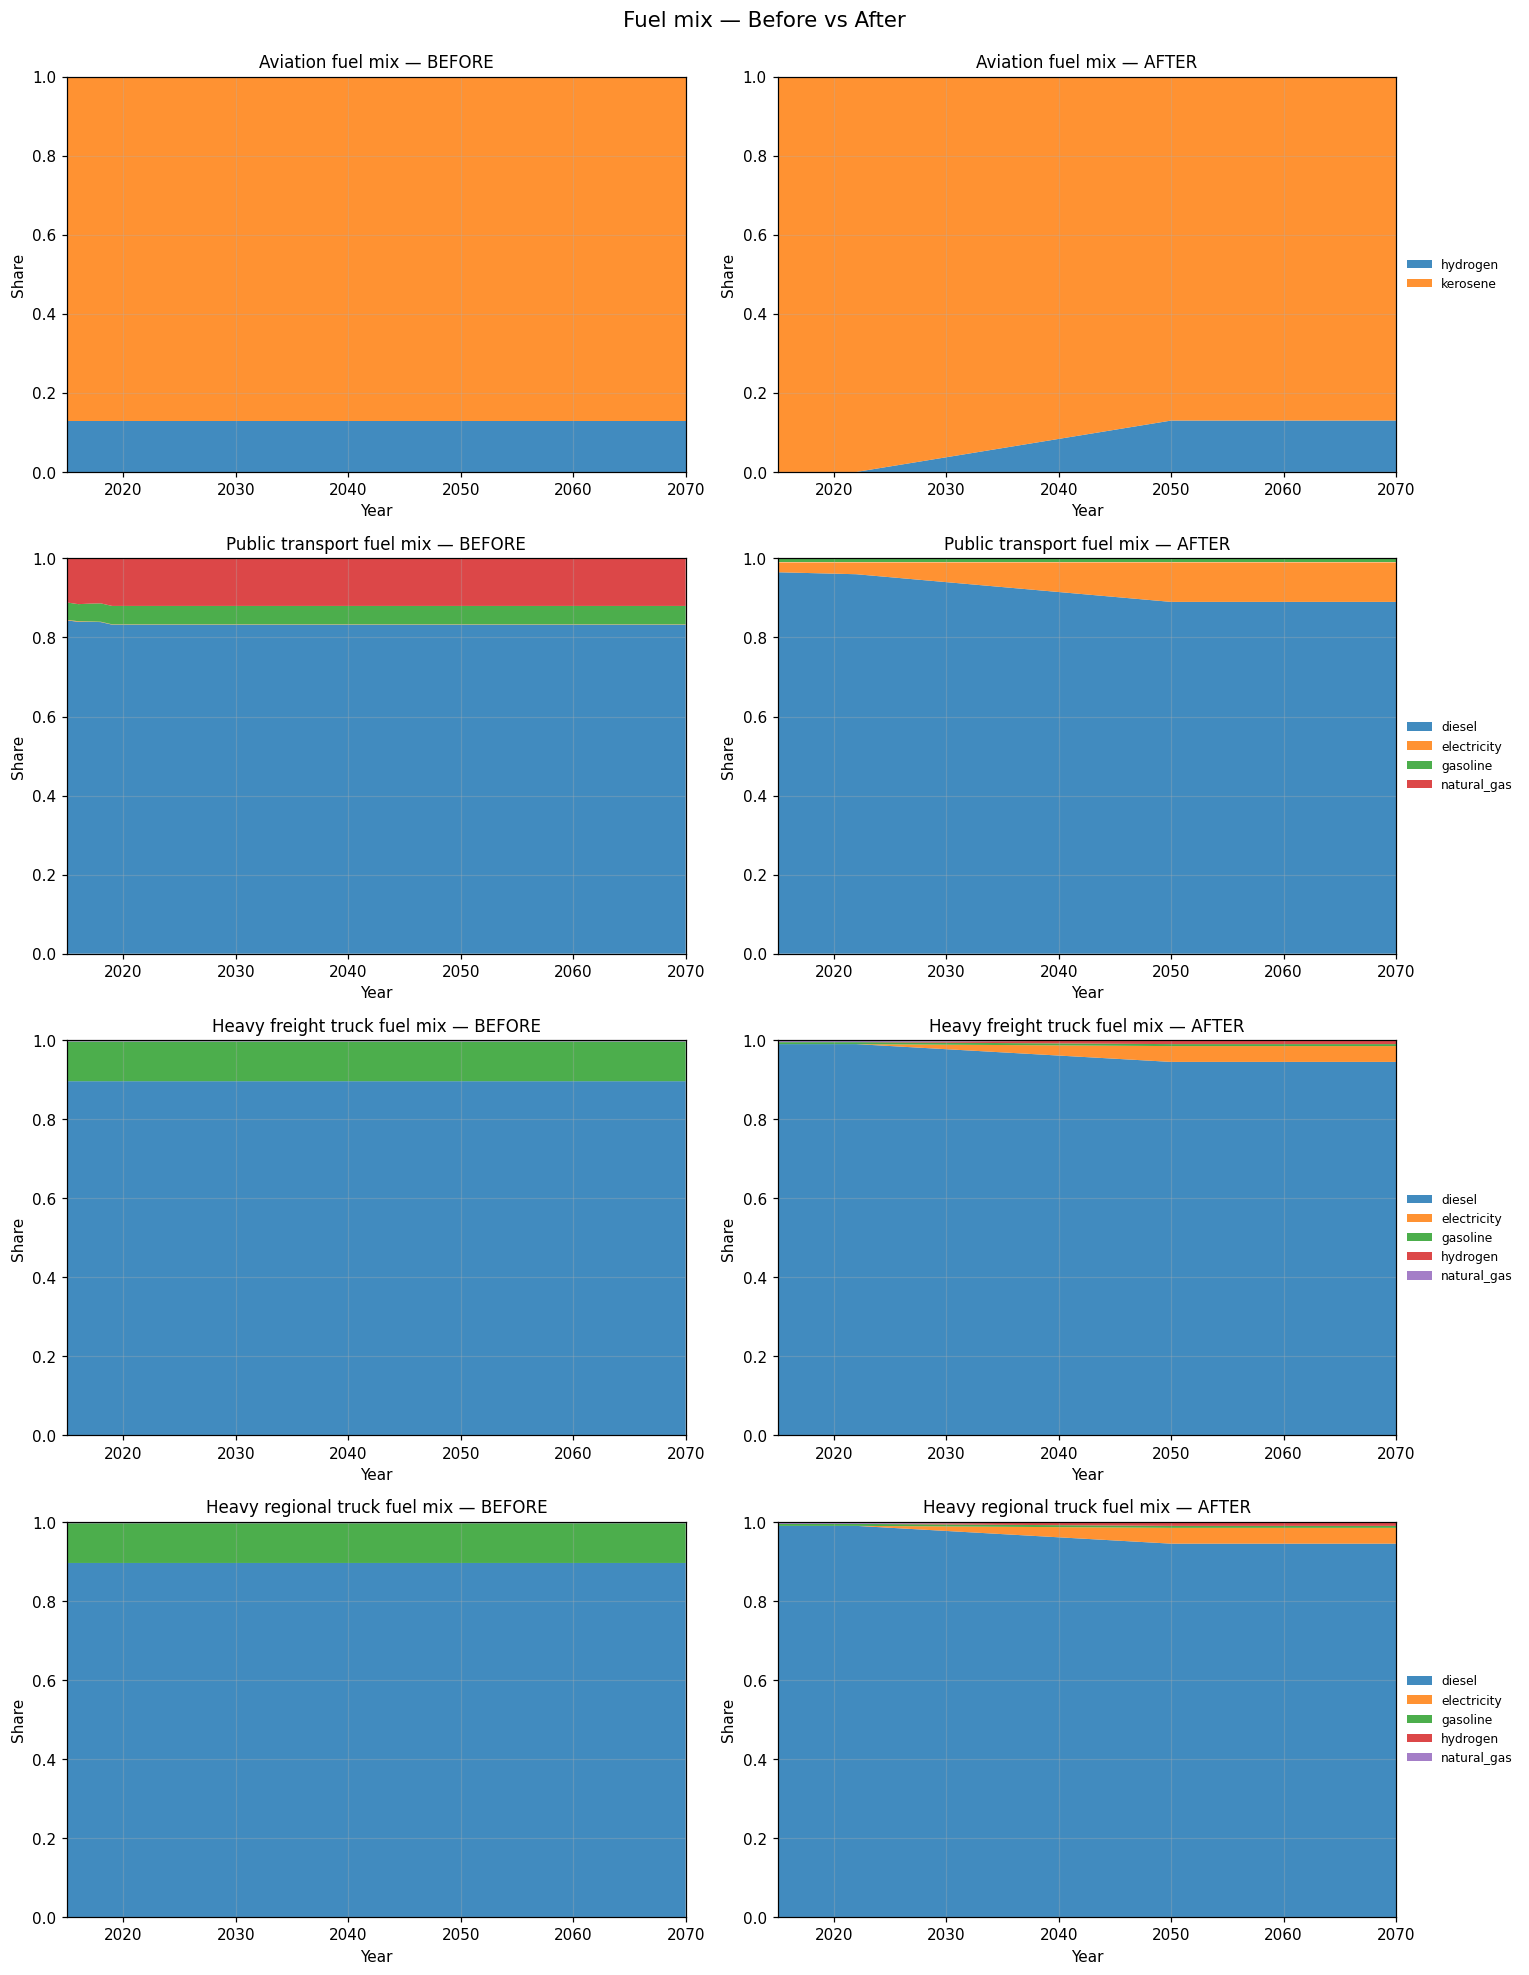

In [27]:
# Stacked area charts for the 4 fuel-mix groups we changed
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
stacked_compare(axes[0,0], axes[0,1], 'frac_trns_fuelmix_aviation_',
                'Aviation fuel mix', df_before, df)
stacked_compare(axes[1,0], axes[1,1], 'frac_trns_fuelmix_public_',
                'Public transport fuel mix', df_before, df)
stacked_compare(axes[2,0], axes[2,1], 'frac_trns_fuelmix_road_heavy_freight_',
                'Heavy freight truck fuel mix', df_before, df)
stacked_compare(axes[3,0], axes[3,1], 'frac_trns_fuelmix_road_heavy_regional_',
                'Heavy regional truck fuel mix', df_before, df)
plt.suptitle('Fuel mix — Before vs After', fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

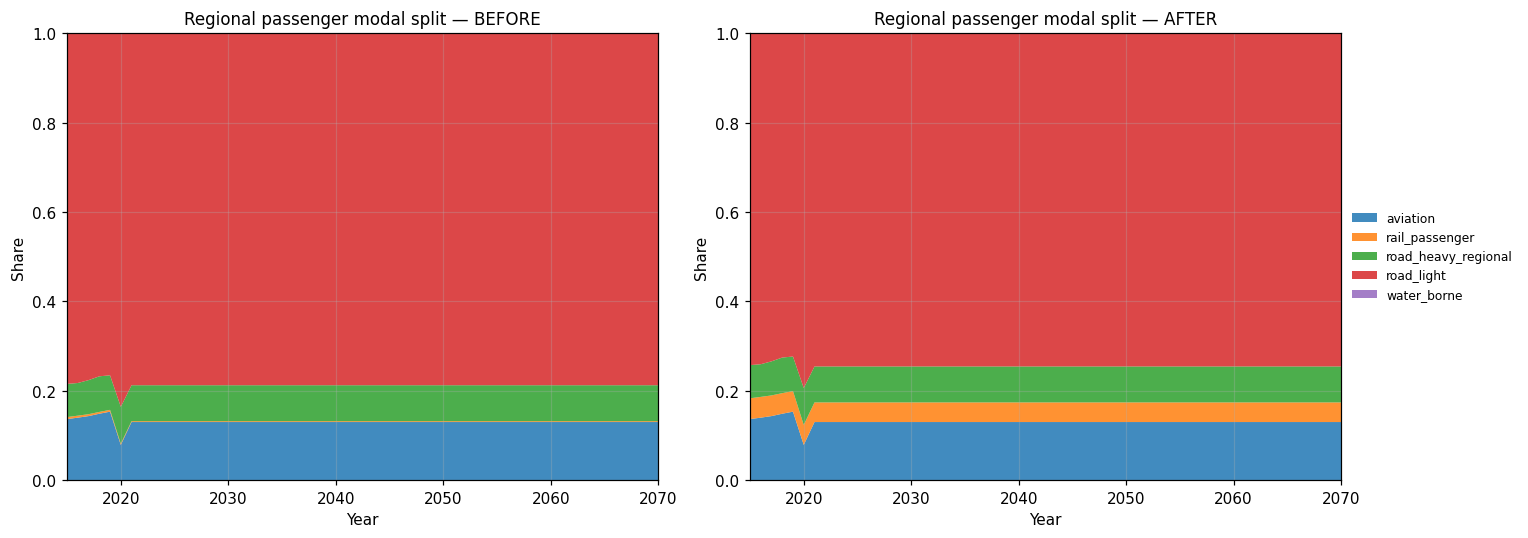

In [28]:
# Modal split — regional (where rail share was raised)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
stacked_compare(axes[0], axes[1], 'frac_trns_pkm_dem_regional_',
                'Regional passenger modal split', df_before, df)
plt.tight_layout()
plt.show()

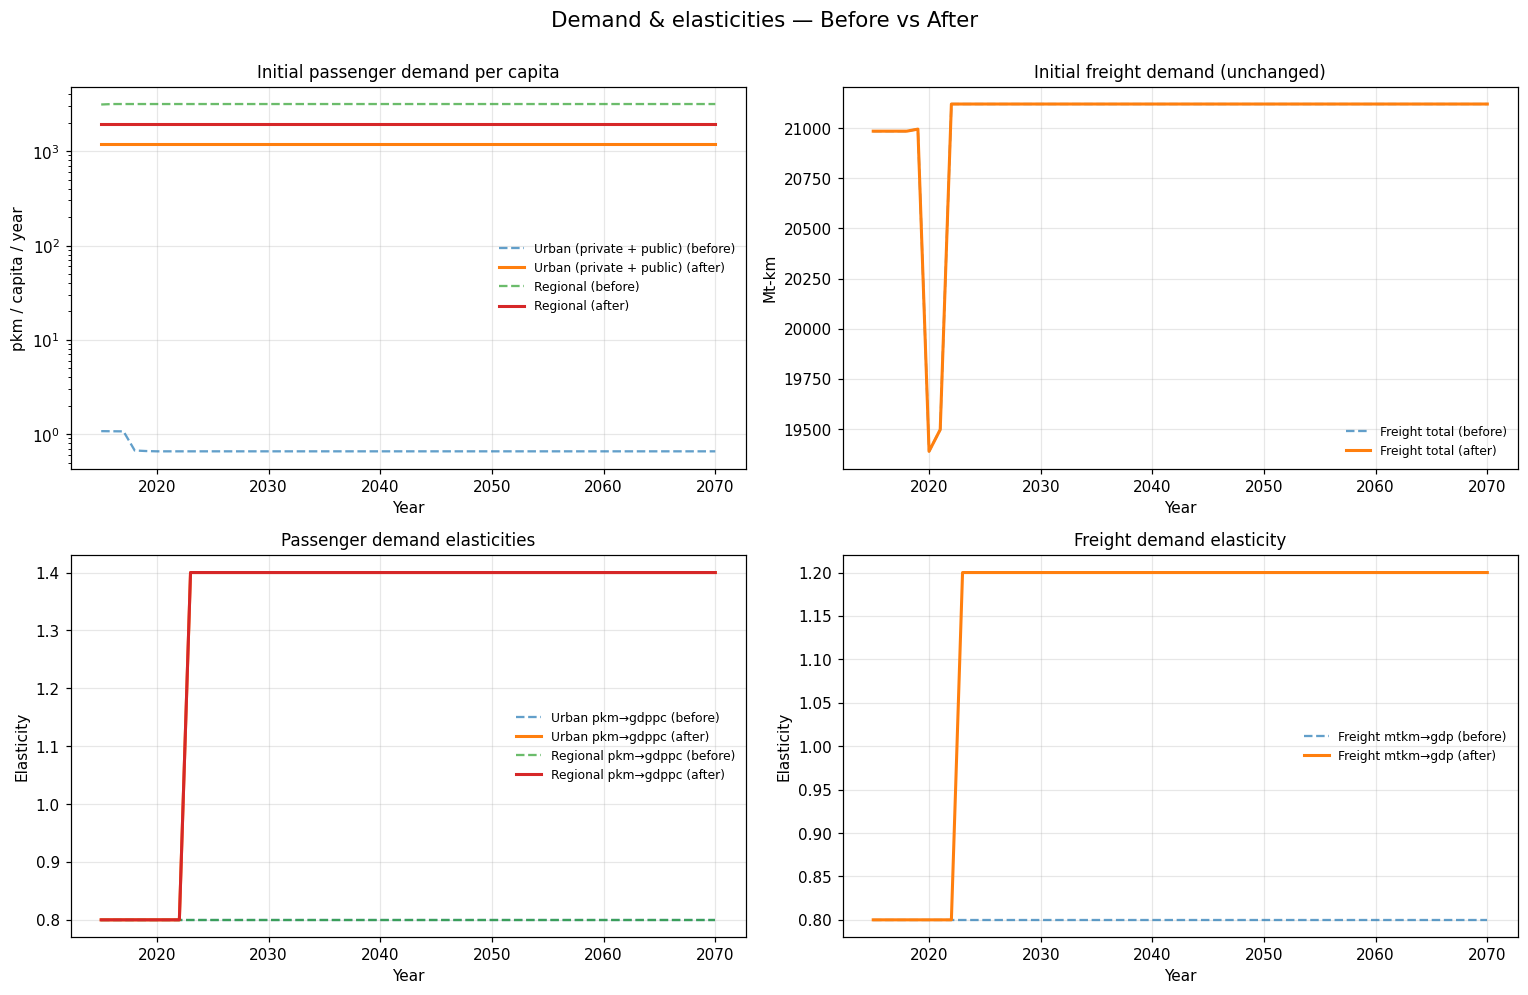

In [29]:
# Initial demand & elasticities — line plots (use log scale for demand because before/after differ ~1800x for urban)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

line_compare(axes[0,0],
    ['deminit_trde_private_and_public_per_capita_passenger_km',
     'deminit_trde_regional_per_capita_passenger_km'],
    ['Urban (private + public)', 'Regional'],
    df_before, df,
    'Initial passenger demand per capita',
    'pkm / capita / year', log=True)

line_compare(axes[0,1],
    ['deminit_trde_freight_mt_km'],
    ['Freight total'],
    df_before, df,
    'Initial freight demand (unchanged)',
    'Mt-km')

line_compare(axes[1,0],
    ['elasticity_trde_pkm_to_gdppc_private_and_public',
     'elasticity_trde_pkm_to_gdppc_regional'],
    ['Urban pkm→gdppc', 'Regional pkm→gdppc'],
    df_before, df,
    'Passenger demand elasticities',
    'Elasticity')

line_compare(axes[1,1],
    ['elasticity_trde_mtkm_to_gdp_freight'],
    ['Freight mtkm→gdp'],
    df_before, df,
    'Freight demand elasticity',
    'Elasticity')

plt.suptitle('Demand & elasticities — Before vs After', fontsize=14, y=1.00)
plt.tight_layout()
plt.show()

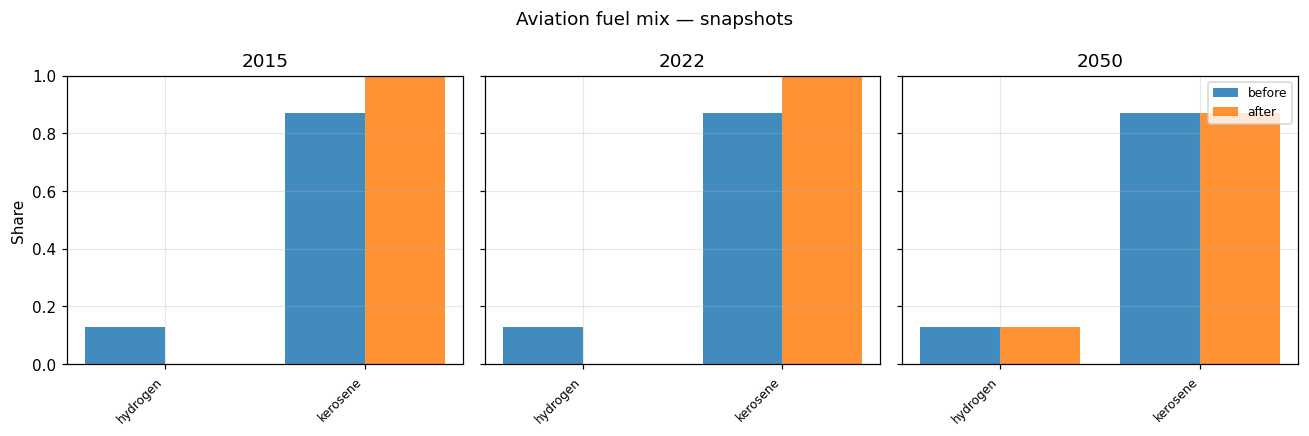

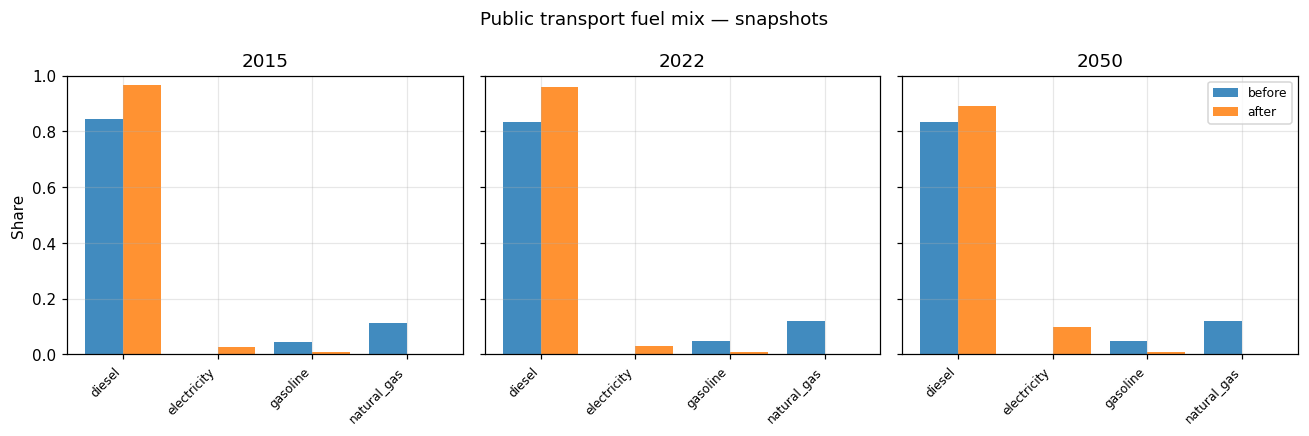

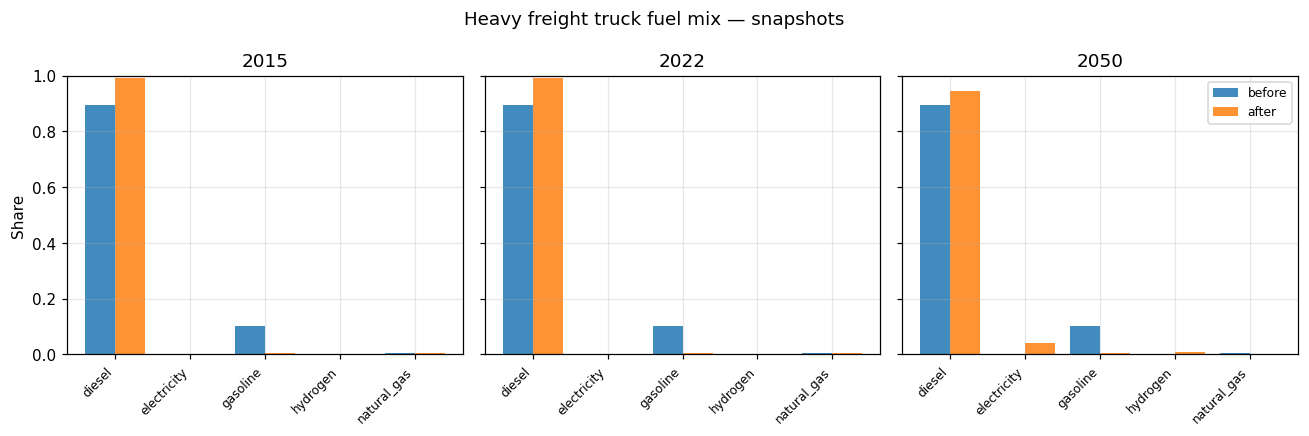

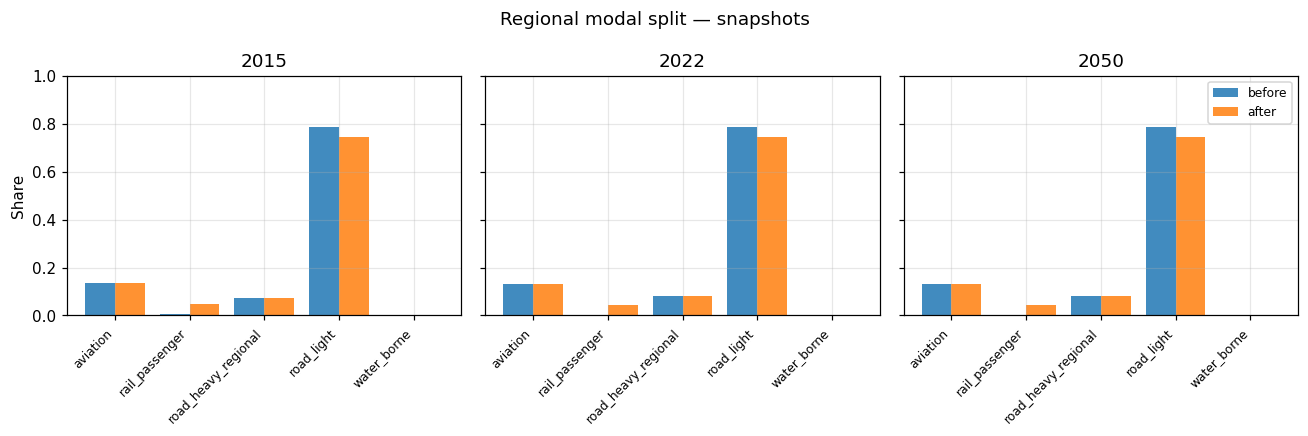

In [30]:
# Snapshot bar charts at three key years: 2015, 2022, 2050
# Shows how the fuel mix shifts at specific years for each affected mode
def snapshot_bars(prefix, title, years=(2015, 2022, 2050)):
    cols = sorted([c for c in df.columns if c.startswith(prefix)])
    labels = [c.replace(prefix,'') for c in cols]
    keep = [i for i, c in enumerate(cols)
            if (df_before[c].abs().max() > 1e-6) or (df[c].abs().max() > 1e-6)]
    cols = [cols[i] for i in keep]; labels = [labels[i] for i in keep]
    fig, axes = plt.subplots(1, len(years), figsize=(4*len(years), 4), sharey=True)
    x = np.arange(len(labels)); w = 0.4
    for i, y in enumerate(years):
        b = df_before.loc[df_before.year==y, cols].iloc[0].values
        a = df.loc[df.year==y, cols].iloc[0].values
        axes[i].bar(x - w/2, b, w, label='before', alpha=0.85)
        axes[i].bar(x + w/2, a, w, label='after',  alpha=0.85)
        axes[i].set_xticks(x); axes[i].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
        axes[i].set_title(f'{y}')
        axes[i].set_ylim(0, 1.0)
        if i == 0: axes[i].set_ylabel('Share')
    axes[-1].legend(loc='upper right', fontsize=8)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

snapshot_bars('frac_trns_fuelmix_aviation_',           'Aviation fuel mix — snapshots')
snapshot_bars('frac_trns_fuelmix_public_',             'Public transport fuel mix — snapshots')
snapshot_bars('frac_trns_fuelmix_road_heavy_freight_', 'Heavy freight truck fuel mix — snapshots')
snapshot_bars('frac_trns_pkm_dem_regional_',           'Regional modal split — snapshots')

In [31]:
# Quick sanity: estimate road_light energy in 2015 to confirm we stayed close to IEA 224 PJ
MOROCCO_POP = {2015: 34.7e6, 2020: 36.7e6, 2022: 37.5e6}
LHV = {'diesel': 36.0, 'gasoline': 32.2, 'kerosene': 35.0}  # MJ/L

def energy_road_light(df_, year):
    p = MOROCCO_POP[year]
    urban_pkm = df_.loc[df_.year==year,'deminit_trde_private_and_public_per_capita_passenger_km'].iloc[0]*p \
                * df_.loc[df_.year==year,'frac_trns_pkm_dem_private_and_public_road_light'].iloc[0]
    reg_pkm   = df_.loc[df_.year==year,'deminit_trde_regional_per_capita_passenger_km'].iloc[0]*p \
                * df_.loc[df_.year==year,'frac_trns_pkm_dem_regional_road_light'].iloc[0]
    total_pkm = urban_pkm + reg_pkm
    occ = df_.loc[df_.year==year,'occrate_trns_passenger_per_vehicle_road_light'].iloc[0]
    vkt = total_pkm / occ
    fmix_d = df_.loc[df_.year==year,'frac_trns_fuelmix_road_light_diesel'].iloc[0]
    fmix_g = df_.loc[df_.year==year,'frac_trns_fuelmix_road_light_gasoline'].iloc[0]
    fe_d   = df_.loc[df_.year==year,'fuelefficiency_trns_road_light_diesel_km_per_litre'].iloc[0]
    fe_g   = df_.loc[df_.year==year,'fuelefficiency_trns_road_light_gasoline_km_per_litre'].iloc[0]
    e_d = vkt*fmix_d/fe_d * LHV['diesel'] / 1e6
    e_g = vkt*fmix_g/fe_g * LHV['gasoline'] / 1e6
    return total_pkm, vkt, e_d, e_g

for label, dfx in [('BEFORE', df_before), ('AFTER', df)]:
    tot, vkt, ed, eg = energy_road_light(dfx, 2015)
    print(f'{label} — Road_light 2015:')
    print(f'  total pkm:        {tot:>20,.0f}')
    print(f'  total vkt:        {vkt:>20,.0f}')
    print(f'  diesel energy:    {ed:>20,.1f} TJ')
    print(f'  gasoline energy:  {eg:>20,.1f} TJ')
    print(f'  road_light total: {ed+eg:>20,.1f} TJ  (~70% of 224 PJ IEA ≈ 157 PJ)\n')

BEFORE — Road_light 2015:
  total pkm:              85,104,496,750
  total vkt:              50,633,327,433
  diesel energy:                89,710.2 TJ
  gasoline energy:              67,554.4 TJ
  road_light total:            157,264.6 TJ  (~70% of 224 PJ IEA ≈ 157 PJ)

AFTER — Road_light 2015:
  total pkm:              88,165,849,249
  total vkt:              52,454,693,746
  diesel energy:                92,937.2 TJ
  gasoline energy:              69,984.5 TJ
  road_light total:            162,921.7 TJ  (~70% of 224 PJ IEA ≈ 157 PJ)



In [32]:
# Save the improved input
df.to_csv(DST, index=False)
print(f'Saved: {DST}')
print(f'Rows: {len(df)}  |  Columns: {len(df.columns)}')

# Diff summary vs original
changed = []
for c in df.columns:
    if 'trns' in c or 'trde' in c:
        if not np.allclose(df[c].values, df_before[c].values, equal_nan=True):
            changed.append(c)
print(f'\nTransport columns modified: {len(changed)} / 183')
for c in changed:
    print(f'  • {c}')

Saved: /Users/fabianfuentes/git/ssp_morocco/ssp_modeling/input_data/sisepuede_raw_inputs_recalibrated_electricity_trns_improved.csv
Rows: 56  |  Columns: 2442

Transport columns modified: 23 / 183
  • deminit_trde_private_and_public_per_capita_passenger_km
  • deminit_trde_regional_per_capita_passenger_km
  • elasticity_trde_mtkm_to_gdp_freight
  • elasticity_trde_pkm_to_gdppc_private_and_public
  • elasticity_trde_pkm_to_gdppc_regional
  • frac_trns_fuelmix_aviation_hydrogen
  • frac_trns_fuelmix_aviation_kerosene
  • frac_trns_fuelmix_public_diesel
  • frac_trns_fuelmix_public_electricity
  • frac_trns_fuelmix_public_gasoline
  • frac_trns_fuelmix_public_natural_gas
  • frac_trns_fuelmix_road_heavy_freight_diesel
  • frac_trns_fuelmix_road_heavy_freight_electricity
  • frac_trns_fuelmix_road_heavy_freight_gasoline
  • frac_trns_fuelmix_road_heavy_freight_hydrogen
  • frac_trns_fuelmix_road_heavy_freight_natural_gas
  • frac_trns_fuelmix_road_heavy_regional_diesel
  • frac_trns_fuelmi